In [2]:
import os
import sys; sys.path.append(os.path.abspath('..'))

from src.environment import WarehouseEnv
from src.planning.fsm_planner import FSMAutomaton
from src.utils.visualization import EnvironmentVisualizer, FunctionVisualizer, create_evaluation_animation
import yaml
from src.utils.buffer import ReplayBuffer

import pickle
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable

with open("../config/warehouse_v1.yaml", 'r') as f:
    config = yaml.safe_load(f)
env = WarehouseEnv(config)
fsm = FSMAutomaton(start_pos = config['fsm']['start_state'], goal_pos = config['fsm']['goal_state'], config=config)


- Step 1: Generate data for training
- Step 2: Pre-training

In [3]:
# now let's inspect the data generated in pretrain_data.pkl 

# Load the pretrain data directly from pickle file
data_path = "../" + config['data_gen']['data_path']
with open(data_path, 'rb') as f:
    data = pickle.load(f)

# Extract data arrays
states = data['states']
actions = data['actions']
next_states = data['next_states']
subgoals = data['subgoals']
rewards = data['rewards']
dones = data['dones']
h_stars = data['h_stars']
v_stars = data['v_stars']

num_transitions = len(states)

print(f"=== Data Inspection: {data_path} ===\n")
print(f"Total transitions: {num_transitions}")
print(f"State dimension: {states.shape[1]}")
print(f"Action dimension: {actions.shape[1]}")
print(f"Subgoal dimension: {subgoals.shape[1]}\n")

# Basic statistics
print("=== Safety Statistics ===")
safe_count = np.sum(h_stars > 0)
unsafe_count = np.sum(h_stars <= 0)
collision_count = np.sum(dones > 0)
print(f"Safe states (h* > 0): {safe_count} ({100*safe_count/num_transitions:.1f}%)")
print(f"Unsafe states (h* <= 0): {unsafe_count} ({100*unsafe_count/num_transitions:.1f}%)")
print(f"Collisions (done=True): {collision_count} ({100*collision_count/num_transitions:.1f}%)\n")

print("=== Value Statistics ===")
print(f"h* (safety): min={h_stars.min():.3f}, max={h_stars.max():.3f}, mean={h_stars.mean():.3f}")
print(f"v* (feasibility): min={v_stars.min():.3f}, max={v_stars.max():.3f}, mean={v_stars.mean():.3f}\n")

=== Data Inspection: ../data/pretrain_data.pkl ===

Total transitions: 30000
State dimension: 5
Action dimension: 2
Subgoal dimension: 2

=== Safety Statistics ===
Safe states (h* > 0): 23565 (78.5%)
Unsafe states (h* <= 0): 6435 (21.4%)
Collisions (done=True): 6435 (21.4%)

=== Value Statistics ===
h* (safety): min=-0.173, max=1.809, mean=0.305
v* (feasibility): min=0.001, max=179.428, mean=39.469



## Understanding Feasibility (v*)

### What is Feasibility?

**Feasibility (v*)** measures how far a state is from reaching a given subgoal. It's computed as:

$$v^*(s, g) = ||p - g||^2$$

where:
- $p$ is the robot's position (first 2 dimensions of state)
- $g$ is the subgoal position
- The value is the **squared Euclidean distance** to the subgoal


### Interpretation

- **Lower v* values** = closer to the subgoal = more feasible
- **Higher v* values** = farther from the subgoal = less feasible
- **v* ≈ 0** = at the subgoal (within epsilon threshold, typically 0.25 = 50cm radius)

### How it was Pre-trained

1. **Ground Truth Generation**: During data generation, v* is computed directly from the squared distance between state position and subgoal position.

2. **Pre-training Phase** (Phase 1):
   - The CLF (Control Lyapunov Function) network `V_ψ(s, g)` is trained to predict v* using **MSE loss**:
     $$L_{pretrain} = ||V_ψ(s, g) - v^*(s, g)||^2$$
   - This "anchors" the CLF to match the ground truth distance function
   - Training uses batches from the collected data for 50 epochs

3. **Main Training Phase** (Phase 2):
   - After pretraining, the CLF is fine-tuned with constraint-based losses:
     - **Goal loss**: Forces V_ψ(s, g) ≈ 0 when at goal (v* ≤ ε)
     - **Constraint loss**: Enforces decrease condition: V(s_{k+1}) ≤ (1-β)V(s_k) + δ
     - **Positivity loss**: Ensures V(s) > 0 for non-goal states
   - This ensures the CLF satisfies Control Lyapunov Function properties for stability

### Why Feasibility Matters

The CLF (feasibility critic) ensures the policy makes progress toward subgoals. During training, the actor is penalized if actions don't decrease the CLF value, forcing the agent to make progress toward goals while maintaining safety (via the CBF).



=== Sample Transitions ===

Transition 12171:
  State: [6.03, 0.61, ...]
  Action: [-1.049, 0.035]
  Next State: [6.03, 0.61, ...]
  Subgoal: [6.00, 5.00]
  h* (safety): 0.465 (SAFE)
  v* (feasibility): 19.233
  Done: 0.0

Transition 3693:
  State: [8.28, 6.81, ...]
  Action: [-1.558, -0.218]
  Next State: [8.28, 6.81, ...]
  Subgoal: [6.00, 5.00]
  h* (safety): 0.161 (SAFE)
  v* (feasibility): 8.492
  Done: 0.0

Transition 19786:
  State: [2.98, 2.39, ...]
  Action: [-1.499, -1.568]
  Next State: [2.98, 2.39, ...]
  Subgoal: [10.50, 8.50]
  h* (safety): -0.040 (UNSAFE)
  v* (feasibility): 93.939
  Done: 1.0

Transition 3165:
  State: [4.59, 3.94, ...]
  Action: [-1.201, 1.006]
  Next State: [4.59, 3.94, ...]
  Subgoal: [6.00, 5.00]
  h* (safety): 0.583 (SAFE)
  v* (feasibility): 3.122
  Done: 0.0

Transition 3366:
  State: [3.30, 8.52, ...]
  Action: [0.380, -0.061]
  Next State: [3.30, 8.51, ...]
  Subgoal: [10.50, 8.50]
  h* (safety): 0.862 (SAFE)
  v* (feasibility): 51.900
  Done:

AttributeError: 'FunctionVisualizer' object has no attribute 'state_positions'

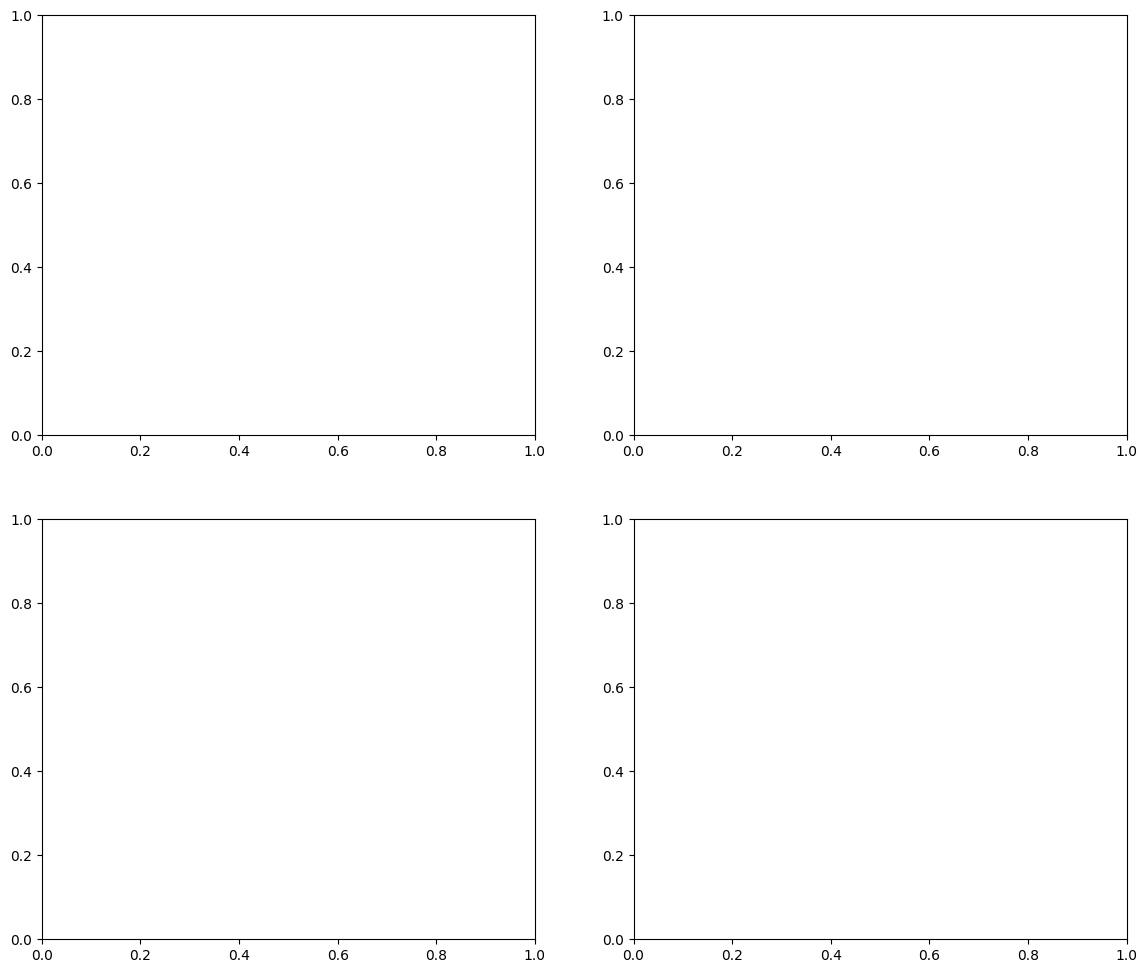

In [4]:

# Sample transitions
print("\n=== Sample Transitions ===")
sample_indices = np.random.choice(num_transitions, min(5, num_transitions), replace=False)
for idx in sample_indices:
    s = states[idx]
    a = actions[idx]
    s_next = next_states[idx]
    g = subgoals[idx]
    h_star_val = h_stars[idx][0]
    v_star_val = v_stars[idx][0]
    done = dones[idx][0]
    
    print(f"\nTransition {idx}:")
    print(f"  State: [{s[0]:.2f}, {s[1]:.2f}, ...]")
    print(f"  Action: [{a[0]:.3f}, {a[1]:.3f}]")
    print(f"  Next State: [{s_next[0]:.2f}, {s_next[1]:.2f}, ...]")
    print(f"  Subgoal: [{g[0]:.2f}, {g[1]:.2f}]")
    print(f"  h* (safety): {h_star_val:.3f} {'(SAFE)' if h_star_val > 0 else '(UNSAFE)'}")
    print(f"  v* (feasibility): {v_star_val:.3f}")
    print(f"  Done: {done}")



# Subgoal distribution
print("=== Subgoal Distribution ===")
subgoals_unique = np.unique(subgoals, axis=0)
print(f"Unique subgoals: {len(subgoals_unique)}")
for i, sg in enumerate(subgoals_unique):
    count = np.sum(np.all(subgoals == sg, axis=1))
    print(f"  Subgoal {i+1}: {sg} ({count} samples, {100*count/num_transitions:.1f}%)")

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

from src.utils.visualization import FunctionVisualizer

f = FunctionVisualizer(env)
f.state_positions(states, h_stars, v_stars, axes[0, 0])
f.safety_distribution(h_stars, axes[0, 1])
f.feasibility_distribution(v_stars, axes[1, 0])
f.subgoal_positions(subgoals, env, subgoals_unique, axes[1, 1])



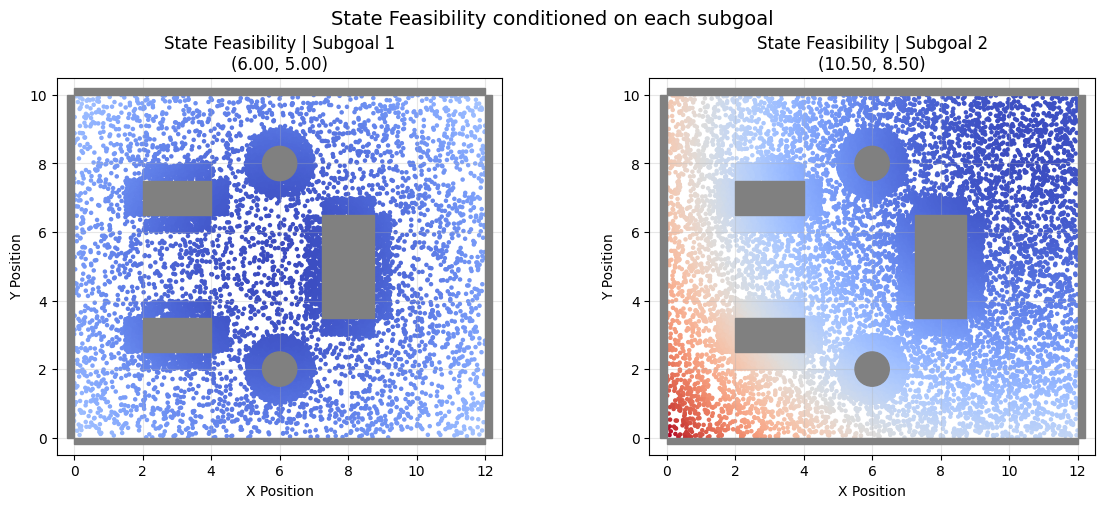

In [ ]:
# Feasibility conditioned on each subgoal

def plot_state_feasibility_views(states, v_stars, subgoals):
    """Visualize v* both in aggregate and conditioned on each subgoal."""
    v_flat = v_stars.flatten()
    vmin, vmax = v_flat.min(), v_flat.max()

    # 2) Small multiples per subgoal for correc
    unique_subgoals = np.unique(subgoals, axis=0)
    num_subgoals = len(unique_subgoals)
    fig_sg, axs = plt.subplots(1, num_subgoals, figsize=(6 * num_subgoals, 5), squeeze=False)
    axs = axs.ravel()

    for idx, (ax, sg) in enumerate(zip(axs, unique_subgoals)):
        mask = np.all(subgoals == sg, axis=1)
        scatter = ax.scatter(states[mask, 0], states[mask, 1], c=v_stars[mask].flatten(),
                             cmap='coolwarm', s=5, vmin=vmin, vmax=vmax)
        ax.set_title(f'State Feasibility | Subgoal {idx + 1}\n({sg[0]:.2f}, {sg[1]:.2f})')
        ax.set_xlabel('X Position')
        ax.set_ylabel('Y Position')
        ax.set_xlim(-0.5, env.workspace[0] + 0.5)
        ax.set_ylim(-0.5, env.workspace[1] + 0.5)
        ax.set_aspect('equal')
        ax.grid(True, alpha=0.3)
        for obs in env.obstacles:
            obs.plot(ax)
    # fig_sg.colorbar(scatter, ax=axs.tolist(), label='v* (distance$^2$)')
    fig_sg.suptitle('State Feasibility conditioned on each subgoal', fontsize=14)
    fig_sg.tight_layout()
    plt.show()


plot_state_feasibility_views(states, v_stars, subgoals)


In [ ]:
 

nn_config = config['nn']
train_config = config['train']

# One trial

env = WarehouseEnv(config)
fsm = FSMAutomaton(
            start_pos=np.array(config['fsm']['start_state']),
            goal_pos=np.array(config['fsm']['goal_state']),
            config=config
    )
buffer = ReplayBuffer(
        state_dim=nn_config['state_dim'], action_dim=nn_config['action_dim'],
        subgoal_dim=nn_config['subgoal_dim'], max_size=train_config['buffer_size']
    )
    
policy_net = SubgoalConditionedPolicy(
        state_dim=nn_config['state_dim'], subgoal_dim=nn_config['subgoal_dim'],
        action_dim=nn_config['action_dim'], hidden_dims=nn_config['hidden_dims'],
        a_max=env.a_max, omega_max=env.omega_max # Pass both maxes
    ).to(device)

cbf_net = CBFNetwork(
    state_dim=nn_config['state_dim'], hidden_dims=nn_config['hidden_dims']
).to(device)

clf_net = CLFNetwork(
    state_dim=nn_config['state_dim'], subgoal_dim=nn_config['subgoal_dim'],
    hidden_dims=nn_config['hidden_dims']
).to(device)

dynamics_net = EnsembleDynamicsModel(
    state_dim=nn_config['state_dim'], action_dim=nn_config['action_dim'],
    hidden_dims=nn_config['hidden_dims'], num_ensemble=nn_config['num_ensemble']
).to(device)

if train_config['load_anchored_models']:
    cbf_net.load_state_dict(torch.load(train_config['anchored_cbf_path'], map_location=device))
    clf_net.load_state_dict(torch.load(train_config['anchored_clf_path'], map_location=device))
    print("Successfully loaded pre-trained CBF and CLF models.")
    
policy_optim = optim.Adam(policy_net.parameters(), lr=train_config['lr_actor'])
cbf_optim = optim.Adam(cbf_net.parameters(), lr=train_config['lr_critic'])
clf_optim = optim.Adam(clf_net.parameters(), lr=train_config['lr_critic'])
dynamics_optim = optim.Adam(dynamics_net.parameters(), lr=train_config['lr_dynamics'])

print(f"--- Starting Main Training (Algorithm 2) ---")
global_step = 0

# 3. Run Training Loop
episode_iterator = tqdm(range(train_config['num_episodes'])) # Re-enabled tqdm

for episode in episode_iterator:
    fsm.reset()
    s_nn = env.reset(start_pos=fsm.start_pos)
    episode_ended = False
    
    # 3a. Run first sub-task: START -> WAYPOINT_1
    g = fsm.get_current_subgoal() # This is waypoint_1
    for t in range(train_config['max_episode_length']):
        global_step += 1
        with torch.no_grad():
            s_torch = torch.from_numpy(s_nn).float().to(device).unsqueeze(0)
            g_torch = torch.from_numpy(g).float().to(device).unsqueeze(0)
            a_det_unscaled = policy_net(s_torch, g_torch).cpu().numpy().squeeze(0)
        
        exploration_noise = train_config['exploration_noise']
        # Add noise to the [-1, 1] action
        a_unscaled = a_det_unscaled + np.random.normal(0, exploration_noise, size=nn_config['action_dim'])
        a_unscaled = np.clip(a_unscaled, -1.0, 1.0)
        
        # Scale action for the environment
        a_scaled = a_unscaled * np.array([env.a_max, env.omega_max])
        
        s_next_nn, _, done, info = env.step(a_scaled)
        v_star = env.get_ground_truth_feasibility(s_next_nn, g)
        collision_penalty = 100.0 if info['is_collision'] else 0.0
        r = -np.sqrt(v_star) - collision_penalty 
        fsm_state = fsm.transition(s_next_nn)
        done = info['is_collision']
        
        buffer.add(s_nn, a_scaled, s_next_nn, g, r, done, info['h_star'], v_star)
        s_nn = s_next_nn
        
        if len(buffer) > train_config['batch_size']:
            if global_step % train_config['model_update_freq'] == 0:
                batch = buffer.sample(train_config['batch_size'])
                b_s, b_a, b_s_next = (torch.from_numpy(batch[k]).float().to(device) for k in ['states', 'actions', 'next_states'])
                _, _ = dynamics_net.compute_loss(b_s, b_a, b_s_next, dynamics_optim)
            if global_step % train_config['cbf_update_freq'] == 0:
                batch = buffer.sample(train_config['batch_size'])
                b_s, b_s_next, b_h_star_next = (torch.from_numpy(batch[k]).float().to(device) for k in ['states', 'next_states', 'h_stars'])
                cbf_optim.zero_grad()
                loss, _ = cbf_net.compute_loss_constraint(b_s, b_s_next, b_h_star_next, config)
                loss.backward()
                cbf_optim.step()
            if global_step % train_config['clf_update_freq'] == 0:
                batch = buffer.sample(train_config['batch_size'])
                b_s, b_s_next, b_g, b_v_star = (torch.from_numpy(batch[k]).float().to(device) for k in ['states', 'next_states', 'subgoals', 'v_stars'])
                clf_optim.zero_grad()
                loss, _ = clf_net.compute_loss_constraint(b_s, b_s_next, b_g, b_v_star, config)
                loss.backward()
                clf_optim.step()
            if global_step % train_config['policy_update_freq'] == 0: # fast and slow time scale they have to be significantly different
                batch = buffer.sample(train_config['batch_size'])
                b_s, b_g, b_s_next_real = (torch.from_numpy(batch[k]).float().to(device) for k in ['states', 'subgoals', 'next_states'])
                
                b_a_mb_unscaled = policy_net(b_s, b_g) # Raw output [-1, 1]
                b_a_mb_scaled = b_a_mb_unscaled * torch.tensor([env.a_max, env.omega_max], device=device, dtype=torch.float32)
                
                b_s_next_pred = dynamics_net(b_s, b_a_mb_scaled)
                
                loss_mb, _, _ = compute_actor_loss(b_s, b_g, b_s_next_pred, cbf_net, clf_net, config)
                loss_mf, _, _ = compute_actor_loss(b_s, b_g, b_s_next_real, cbf_net, clf_net, config)
                
                lambda_mf = train_config['lambda_mf']
                loss = (1.0 - lambda_mf) * loss_mb + lambda_mf * loss_mf
                
                policy_optim.zero_grad()
                for param in cbf_net.parameters(): param.requires_grad = False
                for param in clf_net.parameters(): param.requires_grad = False
                loss.backward()
                policy_optim.step()
                for param in cbf_net.parameters(): param.requires_grad = True
                for param in clf_net.parameters(): param.requires_grad = True
        if done or fsm_state == FSM_STATE_WAYPOINT_1:
            break
    if done: episode_ended = True
    
    # 3b. Run second sub-task: WAYPOINT_1 -> GOAL
    if not episode_ended:
        g = fsm.get_current_subgoal() # This is the final goal
        for t in range(train_config['max_episode_length']):
            global_step += 1
            with torch.no_grad():
                s_torch = torch.from_numpy(s_nn).float().to(device).unsqueeze(0)
                g_torch = torch.from_numpy(g).float().to(device).unsqueeze(0)
                a_det_unscaled = policy_net(s_torch, g_torch).cpu().numpy().squeeze(0)
            
            exploration_noise_lin = train_config['exploration_noise'] * env.a_max 
            exploration_noise_ang = train_config['exploration_noise'] * env.omega_max
            a_unscaled = a_det_unscaled + np.array([np.random.normal(0, exploration_noise_lin), np.random.normal(0, exploration_noise_ang)])
            a_unscaled = np.clip(a_unscaled, -1.0, 1.0)
            a_scaled = a_unscaled * np.array([env.a_max, env.omega_max])

            s_next_nn, _, done, info = env.step(a_scaled)
            v_star = env.get_ground_truth_feasibility(s_next_nn, g)
            collision_penalty = 100.0 if info['is_collision'] else 0.0
            r = -np.sqrt(v_star) - collision_penalty 
            fsm_state = fsm.transition(s_next_nn)
            done = info['is_collision'] or (fsm_state == FSM_STATE_GOAL)
            
            buffer.add(s_nn, a_scaled, s_next_nn, g, r, done, info['h_star'], v_star)
            s_nn = s_next_nn
            
            if len(buffer) > train_config['batch_size']:
                if global_step % train_config['model_update_freq'] == 0:
                    batch = buffer.sample(train_config['batch_size'])
                    b_s, b_a, b_s_next = (torch.from_numpy(batch[k]).float().to(device) for k in ['states', 'actions', 'next_states'])
                    _, _ = dynamics_net.compute_loss(b_s, b_a, b_s_next, dynamics_optim)
                if global_step % train_config['cbf_update_freq'] == 0:
                    batch = buffer.sample(train_config['batch_size'])
                    b_s, b_s_next, b_h_star_next = (torch.from_numpy(batch[k]).float().to(device) for k in ['states', 'next_states', 'h_stars'])
                    cbf_optim.zero_grad()
                    loss, _ = cbf_net.compute_loss_constraint(b_s, b_s_next, b_h_star_next, config)
                    loss.backward()
                    cbf_optim.step()
                if global_step % train_config['clf_update_freq'] == 0:
                    batch = buffer.sample(train_config['batch_size'])
                    b_s, b_s_next, b_g, b_v_star = (torch.from_numpy(batch[k]).float().to(device) for k in ['states', 'next_states', 'subgoals', 'v_stars'])
                    clf_optim.zero_grad()
                    loss, _ = clf_net.compute_loss_constraint(b_s, b_s_next, b_g, b_v_star, config)
                    loss.backward()
                    clf_optim.step()
                if global_step % train_config['policy_update_freq'] == 0:
                    batch = buffer.sample(train_config['batch_size'])
                    b_s, b_g, b_s_next_real = (torch.from_numpy(batch[k]).float().to(device) for k in ['states', 'subgoals', 'next_states'])
                    
                    b_a_mb_unscaled = policy_net(b_s, b_g) # Raw output [-1, 1]
                    b_a_mb_scaled = b_a_mb_unscaled * torch.tensor([env.a_max, env.omega_max], device=device, dtype=torch.float32)
                    
                    b_s_next_pred = dynamics_net(b_s, b_a_mb_scaled)
                    
                    loss_mb, _, _ = compute_actor_loss(b_s, b_g, b_s_next_pred, cbf_net, clf_net, config)
                    loss_mf, _, _ = compute_actor_loss(b_s, b_g, b_s_next_real, cbf_net, clf_net, config)
                    
                    lambda_mf = train_config['lambda_mf']
                    loss = (1.0 - lambda_mf) * loss_mb + lambda_mf * loss_mf
                    
                    policy_optim.zero_grad()
                    for param in cbf_net.parameters(): param.requires_grad = False
                    for param in clf_net.parameters(): param.requires_grad = False
                    loss.backward()
                    policy_optim.step()
                    for param in cbf_net.parameters(): param.requires_grad = True
                    for param in clf_net.parameters(): param.requires_grad = True
            if done:
                break

print(f"--- Main Training Complete (Trial {trial.number}) ---")

# --- 4. RUN EVALUATION ---
policy_net.eval()
cbf_net.eval()
clf_net.eval()
dynamics_net.eval()

eval_buffer = ReplayBuffer(
    state_dim=nn_config['state_dim'], action_dim=nn_config['action_dim'],
    subgoal_dim=nn_config['subgoal_dim'], max_size=config['data_gen']['num_transitions']
)
eval_buffer.load(config['data_gen']['data_path'])

eval_fsm = FSMAutomaton(
    start_pos=np.array(config['fsm']['start_state']),
    goal_pos=np.array(config['fsm']['goal_state']),
    config=config
)

# 4a. Run the FSM check
is_valid, safety_rate, feasibility_rate = eval_fsm.prune_fsm_with_certificates(
    replay_buffer=eval_buffer,
    policy_net=policy_net,
    dynamics_net=dynamics_net,
    cbf_net=cbf_net,
    clf_net=clf_net,
    device=device
)

# 4b. Run the deterministic demo
demo_env = WarehouseEnv(config)
s_nn = demo_env.reset(start_pos=eval_fsm.start_pos)
eval_fsm.reset() 

demo_success = False
episode_ended = False

# Run first leg
for t in range(train_config['max_episode_length']):
    g = eval_fsm.get_current_subgoal()
    with torch.no_grad():
        s_torch = torch.from_numpy(s_nn).float().to(device).unsqueeze(0)
        g_torch = torch.from_numpy(g).float().to(device).unsqueeze(0)
        a_unscaled = policy_net(s_torch, g_torch).cpu().numpy().squeeze(0)
    
    a_scaled = a_unscaled * np.array([demo_env.a_max, demo_env.omega_max])

    s_next_nn, _, _, info = demo_env.step(a_scaled)
    fsm_state = eval_fsm.transition(s_next_nn)
    if info['is_collision']: episode_ended = True; break
    if fsm_state == FSM_STATE_WAYPOINT_1: break
    s_nn = s_next_nn
else: episode_ended = True # Timed out

# Run second leg
if not episode_ended:
    for t in range(train_config['max_episode_length']):
        g = eval_fsm.get_current_subgoal()
        with torch.no_grad():
            s_torch = torch.from_numpy(s_nn).float().to(device).unsqueeze(0)
            g_torch = torch.from_numpy(g).float().to(device).unsqueeze(0)
            a_unscaled = policy_net(s_torch, g_torch).cpu().numpy().squeeze(0)
        
        a_scaled = a_unscaled * np.array([demo_env.a_max, demo_env.omega_max])
        
        s_next_nn, _, _, info = demo_env.step(a_scaled)
        fsm_state = eval_fsm.transition(s_next_nn)
        if info['is_collision']: episode_ended = True; break
        if fsm_state == FSM_STATE_GOAL: 
            demo_success = True # Reached the final goal
            break
        s_nn = s_next_nn
    else: episode_ended = True # Timed out

# --- 5. CALCULATE FINAL SCORE ---
score = 0.0
if is_valid and demo_success:
    score = safety_rate * feasibility_rate

print(f"--- TRIAL {trial.number} COMPLETE ---")
print(f"FSM_Check: {is_valid}, Demo_Success: {demo_success}")
print(f"Avg Safety: {safety_rate:.2f}, Avg Feasibility: {feasibility_rate:.2f}")
print(f"==> Score: {score:.4f}")